# 05 — Tuning des hyperparamètres

**Phase 3 — Livrable 2**

Objectifs :
1. Charger la meilleure combinaison modèle × stratégie (notebook 04)
2. Définir et justifier la grille d'hyperparamètres
3. Optimiser avec GridSearchCV / RandomizedSearchCV
4. Comparer avant/après tuning
5. Sauvegarder le meilleur modèle tuné

**Métrique d'optimisation** : F1-score (classe 1)

## 1. Setup et chargement des résultats de la Phase 04

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, make_scorer
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print("Imports OK")

Imports OK


In [2]:
# Chargement des résultats du notebook 04
with open('../models/modeling_results.json', 'r', encoding='utf-8') as f:
    modeling_results = json.load(f)

BEST_MODEL_NAME  = modeling_results['best_model']
BEST_STRATEGY    = modeling_results['best_strategy']
SCALE_POS_WEIGHT = modeling_results['scale_pos_weight']
MODEL_NAME_USED  = modeling_results['model_name_used']

print(f"Meilleur modèle    : {BEST_MODEL_NAME}")
print(f"Meilleure stratégie: {BEST_STRATEGY}")
print(f"F1 avant tuning    : {modeling_results['best_f1_mean']:.4f} ± {modeling_results['best_f1_std']:.4f}")
print(f"scale_pos_weight   : {SCALE_POS_WEIGHT:.2f}")

Meilleur modèle    : GradientBoosting
Meilleure stratégie: class_weight
F1 avant tuning    : 0.8036 ± 0.0171
scale_pos_weight   : 5.67


## 2. Rechargement des données (identique notebook 04)

In [3]:
# Rechargement depuis les splits sauvegardés
train_df = pd.read_csv('../data/processed/train.csv')
val_df   = pd.read_csv('../data/processed/validation.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=['is_inactive'])
y_train = train_df['is_inactive']
X_val   = val_df.drop(columns=['is_inactive'])
y_val   = val_df['is_inactive']
X_test  = test_df.drop(columns=['is_inactive'])
y_test  = test_df['is_inactive']

print(f"Train : {X_train.shape}, Val : {X_val.shape}, Test : {X_test.shape}")

# Colonnes par type
num_cols = ['stars', 'forks', 'open_issues', 'watchers', 'size_kb',
            'repo_age_days', 'contributor_count', 'avg_issue_response_hours',
            'engagement_rate', 'stars_forks_ratio',
            'activity_score', 'issues_per_contributor']
cat_cols = ['language', 'license', 'age_category']
bin_cols = ['has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork']

def make_preprocessor():
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
        ('bin', 'passthrough', bin_cols)
    ], remainder='drop')

print("Preprocessor factory définie")

Train : (10500, 20), Val : (2250, 20), Test : (2250, 20)
Preprocessor factory définie


---
## 3. Grilles d'hyperparamètres et justifications

Les plages sont choisies selon des principes documentés ci-dessous.

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# GRILLES D'HYPERPARAMÈTRES PAR MODÈLE
# Chaque clé est préfixée par 'classifier__' (nom du step pipeline)
# ──────────────────────────────────────────────────────────────────────────────

param_grids = {

    'Logistic Regression': {
        # C : régularisation inverse. Plage log-uniforme [0.01, 10]
        # Justification : C < 0.1 → sur-régularisation sur 15k samples
        #                 C > 10  → sous-régularisation sans gain notable
        # penalty : l2 (standard, solver lbfgs)
        'grid_type': 'grid',
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs'],
            'classifier__class_weight': ['balanced'],
            'classifier__max_iter': [5000]
        }
    },

    'Decision Tree': {
        # max_depth : [3,5,7,10] — évite sur-apprentissage sans trop contraindre
        #   < 3 : underfitting  |  > 10 : overfitting quasi-certain
        # min_samples_leaf : [1,5,10,20] — régularisation par feuilles minimum
        'grid_type': 'grid',
        'params': {
            'classifier__max_depth': [3, 5, 7, 10],
            'classifier__min_samples_leaf': [1, 5, 10, 20],
            'classifier__class_weight': ['balanced']
        }
    },

    'GradientBoosting': {
        # n_estimators [100,300] : au-delà peu de gain
        # max_depth [3,5] : boosting fonctionne mieux avec arbres peu profonds
        # learning_rate [0.05,0.1] : lr faible + plus d'arbres = meilleure généralisation
        'grid_type': 'random',
        'n_iter': 20,
        'params': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__subsample': [0.7, 0.8, 1.0],
            'classifier__min_samples_leaf': [1, 5, 10]
        }
    },

    'XGBoost': {
        # max_depth [3,5,7] : boosting préfère arbres peu profonds
        # learning_rate [0.01,0.05,0.1] : lr 0.01 → plus lent mais robuste
        # n_estimators [100,300,500] : avec early_stopping
        # subsample/colsample : régularisation stochastique [0.7,1.0]
        # scale_pos_weight : FIXÉ au ratio train — gère le déséquilibre
        'grid_type': 'random',
        'n_iter': 20,
        'params': {
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__n_estimators': [100, 300, 500],
            'classifier__subsample': [0.7, 0.8, 1.0],
            'classifier__colsample_bytree': [0.7, 0.8, 1.0]
        }
    },

    'MLP': {
        # hidden_layer_sizes : architectures testées de la moins à la plus complexe
        # alpha : régularisation L2 — [0.0001,0.01] plage standard sklearn
        # learning_rate_init : adam [0.0001,0.001] pour éviter divergence
        'grid_type': 'random',
        'n_iter': 15,
        'params': {
            'classifier__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
            'classifier__activation': ['relu', 'tanh'],
            'classifier__alpha': [0.0001, 0.001, 0.01],
            'classifier__learning_rate_init': [0.0001, 0.001],
            'classifier__max_iter': [500]
        }
    }
}

print("Grilles d'hyperparamètres définies.")
print(f"Modèle à tuner : {BEST_MODEL_NAME}")

Grilles d'hyperparamètres définies.
Modèle à tuner : GradientBoosting


---
## 4. Tuning du meilleur modèle

In [5]:
def build_base_model(model_name, strategy, scale_pos_weight):
    """Retourne (classifier, sampler_steps)"""
    if model_name == 'Logistic Regression':
        if strategy == 'class_weight':
            clf = LogisticRegression(class_weight='balanced', max_iter=5000,
                                      solver='lbfgs', random_state=RANDOM_STATE)
        else:
            clf = LogisticRegression(max_iter=5000, solver='lbfgs',
                                      random_state=RANDOM_STATE)
    elif model_name == 'Decision Tree':
        if strategy == 'class_weight':
            clf = DecisionTreeClassifier(class_weight='balanced',
                                          random_state=RANDOM_STATE)
        else:
            clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
    elif model_name in ('XGBoost', 'GradientBoosting'):
        if XGB_AVAILABLE:
            clf = XGBClassifier(scale_pos_weight=scale_pos_weight,
                                 random_state=RANDOM_STATE,
                                 eval_metric='logloss', verbosity=0)
        else:
            clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    elif model_name == 'MLP':
        clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500,
                             early_stopping=True, random_state=RANDOM_STATE)
    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    if strategy == 'SMOTE':
        sampler = [('sampler', SMOTE(random_state=RANDOM_STATE))]
    elif strategy == 'Undersampling':
        sampler = [('sampler', RandomUnderSampler(random_state=RANDOM_STATE))]
    else:
        sampler = []

    return clf, sampler


clf_base, sampler_steps = build_base_model(
    BEST_MODEL_NAME, BEST_STRATEGY, SCALE_POS_WEIGHT)

pipeline_base = ImbPipeline(
    [('preprocessor', make_preprocessor())] +
    sampler_steps +
    [('classifier', clf_base)]
)

print(f"Pipeline de base construit : {BEST_MODEL_NAME} + {BEST_STRATEGY}")
print(pipeline_base)

Pipeline de base construit : GradientBoosting + class_weight
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['stars', 'forks',
                                                   'open_issues', 'watchers',
                                                   'size_kb', 'repo_age_days',
                                                   'contributor_count',
                                                   'avg_issue_response_hours',
                                                   'engagement_rate',
                                                   'stars_f

In [6]:
# Sélection de la grille selon le modèle
model_key = BEST_MODEL_NAME
if 'XGBoost' in model_key or 'GradientBoosting' in model_key:
    grid_key = 'XGBoost' if XGB_AVAILABLE else 'GradientBoosting'
else:
    grid_key = model_key

grid_config = param_grids[grid_key]
grid_type   = grid_config['grid_type']
param_space = grid_config['params']

cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=1)

print(f"Type de recherche : {grid_type.upper()}")
print(f"Nombre de paramètres : {len(param_space)}")
print(f"Espace de recherche :")
for k, v in param_space.items():
    print(f"  {k} : {v}")

Type de recherche : RANDOM
Nombre de paramètres : 5
Espace de recherche :
  classifier__n_estimators : [100, 200, 300]
  classifier__max_depth : [3, 5, 7]
  classifier__learning_rate : [0.01, 0.05, 0.1]
  classifier__subsample : [0.7, 0.8, 1.0]
  classifier__min_samples_leaf : [1, 5, 10]


In [7]:
# ─── Exécution de la recherche d'hyperparamètres ──────────────────────────────
print(f"Lancement du tuning ({grid_type.upper()})...")
print("(Peut prendre plusieurs minutes selon le modèle)")

if grid_type == 'grid':
    search = GridSearchCV(
        pipeline_base,
        param_grid=param_space,
        cv=cv_tuning,
        scoring=f1_scorer,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
else:
    n_iter = grid_config.get('n_iter', 20)
    search = RandomizedSearchCV(
        pipeline_base,
        param_distributions=param_space,
        n_iter=n_iter,
        cv=cv_tuning,
        scoring=f1_scorer,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE,
        refit=True
    )

search.fit(X_train, y_train)

print(f"\n✓ Tuning terminé.")
print(f"Meilleur F1 (CV) : {search.best_score_:.4f}")
print(f"Meilleurs paramètres :")
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

Lancement du tuning (RANDOM)...
(Peut prendre plusieurs minutes selon le modèle)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Tuning terminé.
Meilleur F1 (CV) : 0.8062
Meilleurs paramètres :
  classifier__subsample = 1.0
  classifier__n_estimators = 300
  classifier__min_samples_leaf = 1
  classifier__max_depth = 3
  classifier__learning_rate = 0.1


---
## 5. Analyse des résultats du tuning

In [8]:
# Extraction des résultats de CV
cv_results = pd.DataFrame(search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

print(f"Top 10 configurations :")
top_cols = ['mean_test_score', 'std_test_score', 'rank_test_score']
param_cols = [c for c in cv_results.columns if c.startswith('param_classifier__')]
print(cv_results[top_cols + param_cols].head(10).to_string(index=False))

Top 10 configurations :
 mean_test_score  std_test_score  rank_test_score  param_classifier__subsample  param_classifier__n_estimators  param_classifier__min_samples_leaf  param_classifier__max_depth  param_classifier__learning_rate
        0.806184        0.017480                1                          1.0                             300                                   1                            3                             0.10
        0.805998        0.021402                2                          0.8                             200                                   5                            3                             0.10
        0.805516        0.016247                3                          0.8                             100                                  10                            5                             0.05
        0.804502        0.014955                4                          1.0                             100                              

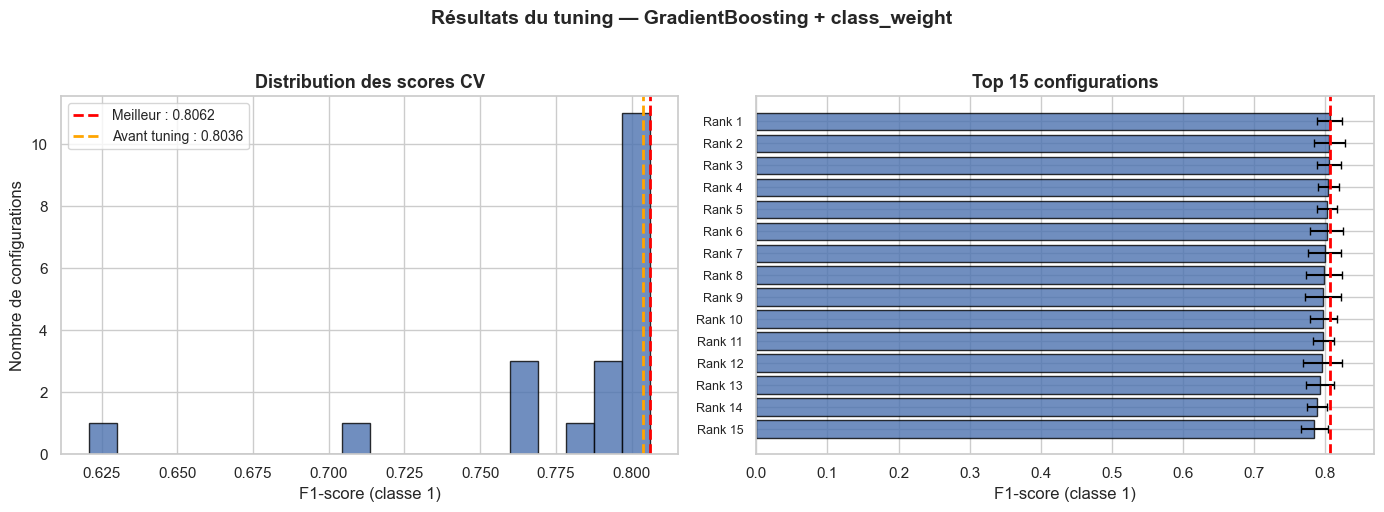

In [9]:
# Visualisation : distribution des scores CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des scores
axes[0].hist(cv_results['mean_test_score'], bins=20, color='#4C72B0',
             edgecolor='black', alpha=0.8)
axes[0].axvline(search.best_score_, color='red', linestyle='--', linewidth=2,
                label=f'Meilleur : {search.best_score_:.4f}')
axes[0].axvline(modeling_results['best_f1_mean'], color='orange', linestyle='--',
                linewidth=2, label=f'Avant tuning : {modeling_results["best_f1_mean"]:.4f}')
axes[0].set_xlabel('F1-score (classe 1)', fontsize=12)
axes[0].set_ylabel('Nombre de configurations', fontsize=12)
axes[0].set_title('Distribution des scores CV', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Top 15 configurations
top15 = cv_results.head(15)
axes[1].barh(range(len(top15)), top15['mean_test_score'],
              color='#4C72B0', alpha=0.8, edgecolor='black')
axes[1].errorbar(top15['mean_test_score'], range(len(top15)),
                  xerr=top15['std_test_score'], fmt='none',
                  ecolor='black', capsize=3)
axes[1].axvline(search.best_score_, color='red', linestyle='--', linewidth=2)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f'Rank {r}' for r in range(1, len(top15)+1)], fontsize=9)
axes[1].set_xlabel('F1-score (classe 1)', fontsize=12)
axes[1].set_title('Top 15 configurations', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle(f'Résultats du tuning — {BEST_MODEL_NAME} + {BEST_STRATEGY}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Comparaison avant / après tuning sur le jeu de validation
print("=" * 60)
print("COMPARAISON AVANT / APRÈS TUNING")
print("=" * 60)

pipeline_before = joblib.load('../models/best_pipeline_before_tuning.joblib')
pipeline_before.fit(X_train, y_train)
y_pred_before = pipeline_before.predict(X_val)

best_tuned_pipeline = search.best_estimator_
y_pred_after = best_tuned_pipeline.predict(X_val)

print("\n--- AVANT TUNING ---")
print(classification_report(y_val, y_pred_before,
                              target_names=['Actif (0)', 'Inactif (1)']))

print("\n--- APRÈS TUNING ---")
print(classification_report(y_val, y_pred_after,
                              target_names=['Actif (0)', 'Inactif (1)']))

metrics_comparison = pd.DataFrame({
    'Avant tuning': {
        'F1 (classe 1)': f1_score(y_val, y_pred_before, pos_label=1),
        'Recall (classe 1)': recall_score(y_val, y_pred_before, pos_label=1),
        'Precision (classe 1)': precision_score(y_val, y_pred_before, pos_label=1)
    },
    'Après tuning': {
        'F1 (classe 1)': f1_score(y_val, y_pred_after, pos_label=1),
        'Recall (classe 1)': recall_score(y_val, y_pred_after, pos_label=1),
        'Precision (classe 1)': precision_score(y_val, y_pred_after, pos_label=1)
    }
})
print("\nTableau comparatif :")
print(metrics_comparison.round(4))

COMPARAISON AVANT / APRÈS TUNING

--- AVANT TUNING ---
              precision    recall  f1-score   support

   Actif (0)       0.96      0.97      0.97      1912
 Inactif (1)       0.84      0.80      0.82       338

    accuracy                           0.95      2250
   macro avg       0.90      0.88      0.89      2250
weighted avg       0.94      0.95      0.95      2250


--- APRÈS TUNING ---
              precision    recall  f1-score   support

   Actif (0)       0.97      0.97      0.97      1912
 Inactif (1)       0.85      0.82      0.83       338

    accuracy                           0.95      2250
   macro avg       0.91      0.90      0.90      2250
weighted avg       0.95      0.95      0.95      2250


Tableau comparatif :
                      Avant tuning  Après tuning
F1 (classe 1)               0.8152        0.8313
Recall (classe 1)           0.7959        0.8166
Precision (classe 1)        0.8354        0.8466


---
## 6. Sauvegarde du modèle tuné

In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_tuned_pipeline, '../models/tuned_pipeline.joblib')

tuning_metadata = {
    'model_name': BEST_MODEL_NAME,
    'strategy': BEST_STRATEGY,
    'best_params': {k: str(v) for k, v in search.best_params_.items()},
    'best_cv_f1': float(search.best_score_),
    'f1_before_tuning': float(modeling_results['best_f1_mean']),
    'improvement': float(search.best_score_ - modeling_results['best_f1_mean']),
    'val_f1_after_tuning': float(f1_score(y_val, y_pred_after, pos_label=1)),
    'val_recall_after_tuning': float(recall_score(y_val, y_pred_after, pos_label=1)),
    'val_precision_after_tuning': float(precision_score(y_val, y_pred_after, pos_label=1))
}

with open('../models/tuning_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(tuning_metadata, f, indent=2, ensure_ascii=False)

print("Modèle tuné sauvegardé :")
print("  models/tuned_pipeline.joblib")
print("  models/tuning_metadata.json")
print()
print("=" * 60)
print("RÉSUMÉ DU TUNING")
print("=" * 60)
print(f"Modèle    : {BEST_MODEL_NAME}")
print(f"Stratégie : {BEST_STRATEGY}")
print(f"F1 avant  : {modeling_results['best_f1_mean']:.4f}")
print(f"F1 après  : {search.best_score_:.4f} (CV) / {tuning_metadata['val_f1_after_tuning']:.4f} (val)")
print(f"Gain      : +{tuning_metadata['improvement']:.4f}")
print()
print("→ Le modèle tuné sera évalué sur le test set dans notebook 06_evaluation.ipynb")


Modèle tuné sauvegardé :
  models/tuned_pipeline.joblib
  models/tuning_metadata.json

RÉSUMÉ DU TUNING
Modèle    : GradientBoosting
Stratégie : class_weight
F1 avant  : 0.8036
F1 après  : 0.8062 (CV) / 0.8313 (val)
Gain      : +0.0026

→ Le modèle tuné sera évalué sur le test set dans notebook 06_evaluation.ipynb
